In [1]:
# ============================================================
# EfficientNetV2-M (TF 2.20 + Keras 3)
# Dermatology-Optimized Pipeline with Fine-Tuning
# ============================================================

import os
import keras
import tensorflow as tf
from keras import layers
from keras.utils import image_dataset_from_directory

# Correct import for TF2.20 / Keras3
from keras.applications.efficientnet_v2 import EfficientNetV2M, preprocess_input

2025-11-15 16:50:31.384353: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# ============================================================
# GPU CHECK
# ============================================================
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU Available:", gpus)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected.")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
TRAIN_DIR  = "dataset/train"
VAL_DIR    = "dataset/valid"
TEST_DIR   = "dataset/test"

OUTPUT_DIR = "./efficientnetv2m_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:

# ============================================================
# HYPERPARAMETERS
# ============================================================
IMAGE_SIZE = (300, 300)   # Slightly lower than default to avoid OOM
BATCH_SIZE = 16
NUM_CLASSES = 7
SEED = 42

EPOCHS = 12
LR = 1e-4
AUTOTUNE = tf.data.AUTOTUNE
USE_MIXED_PRECISION = True

In [5]:
# ============================================================
# Mixed Precision for SPEED + low VRAM use
# ============================================================
if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")

Mixed precision enabled.


In [6]:

# ============================================================
# DATA LOADER
# ============================================================

def load_ds(path, shuffle=True):
    ds = image_dataset_from_directory(
        path,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=shuffle,
        seed=SEED
    )
    return ds.prefetch(AUTOTUNE)

train_ds = load_ds(TRAIN_DIR, shuffle=True)
val_ds   = load_ds(VAL_DIR, shuffle=False)
test_ds  = load_ds(TEST_DIR, shuffle=False)


Found 41995 files belonging to 7 classes.


I0000 00:00:1763225438.236706  502445 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43742 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:34:00.0, compute capability: 8.9


Found 3499 files belonging to 7 classes.
Found 3499 files belonging to 7 classes.


In [7]:
# ============================================================
# SKIN-DISEASE OPTIMIZED AUGMENTATION
# ============================================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
    layers.GaussianNoise(0.02),
], name="derma_aug")



In [8]:
# ============================================================
# PREPROCESSING
# ============================================================
def preprocess_train(images, labels):
    images = preprocess_input(images)
    images = data_augmentation(images)
    return images, labels

def preprocess_eval(images, labels):
    images = preprocess_input(images)
    return images, labels

train_ds = train_ds.map(preprocess_train, AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval, AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval, AUTOTUNE)

In [9]:
# ============================================================
# BUILD MODEL — EfficientNetV2-M
# ============================================================
base_model = EfficientNetV2M(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

base_model.trainable = False  # Stage 1 (frozen backbone)

inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="EfficientNetV2-M")
model.summary()

Model: "EfficientNetV2-M"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 1280)           │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,159,355 (202.79 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

In [29]:
# ============================================================
# COMPILE
# ============================================================
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5),
    ]
)


# ============================================================
# CALLBACKS
# ============================================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_v2m.keras"),
        save_best_only=True,
        monitor="val_loss",
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
]


# ============================================================
# TRAIN PHASE 1 (Frozen)
# ============================================================
print("\nTraining EfficientNetV2-M (Frozen)…\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Training EfficientNetV2-M (Frozen)…

Epoch 1/12
2623/2625 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3113 - loss: 1.7586 - sparse_top_k_categorical_accuracy: 0.6465 - sparse_top_k_categorical_accuracy_1: 0.8563

2025-11-15 15:31:52.896709: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 461.97MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2625/2625 ━━━━━━━━━━━━━━━━━━━━ 297s 83ms/step - accuracy: 0.3975 - loss: 1.6169 - sparse_top_k_categorical_accuracy: 0.7290 - sparse_top_k_categorical_accuracy_1: 0.9029 - val_accuracy: 0.5007 - val_loss: 1.3858 - val_sparse_top_k_categorical_accuracy: 0.8182 - val_sparse_top_k_categorical_accuracy_1: 0.9503 - learning_rate: 1.0000e-04
Epoch 2/12
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 109s 41ms/step - accuracy: 0.5160 - loss: 1.3704 - sparse_top_k_categorical_accuracy: 0.8160 - sparse_top_k_categorical_accuracy_1: 0.9448 - val_accuracy: 0.5564 - val_loss: 1.2576 - val_sparse_top_k_categorical_accuracy: 0.8508 - val_sparse_top_k_categorical_accuracy_1: 0.9594 - learning_rate: 1.0000e-04
Epoch 3/12
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 111s 42ms/step - accuracy: 0.5462 - loss: 1.2884 - sparse_top_k_categorical_accuracy: 0.8369 - sparse_top_k_categorical_accuracy_1: 0.9504 - val_accuracy: 0.5845 - val_loss: 1.1949 - val_sparse_top_k_categorical_accuracy: 0.8677 - val_sparse_top_k_categorical_accuracy_1:

In [10]:
# ============================================================
# LOAD YOUR TRAINED MODEL
# ============================================================

MODEL_PATH = "efficientnetv2m_output/best_v2m.keras"

print("Loading trained model...")
model = keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

# Extract the EfficientNetV2-M backbone
# (the "base_model" is always the first layer inside the Functional model)
base_model = model.layers[1]
print("Backbone extracted:", base_model.name)

Loading trained model...
Model loaded successfully!
Backbone extracted: efficientnetv2-m


In [15]:
# ============================================================
# CALLBACKS (THEY WERE MISSING)
# ============================================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "finetuned_v2m.keras"),
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
]

In [13]:
import keras
import tensorflow as tf
from keras.applications.efficientnet_v2 import EfficientNetV2M, preprocess_input

In [16]:
# ============================================================
# FINE-TUNE FUNCTION
# ============================================================

def fine_tune_loaded_model(model, base_model, unfreeze_last=60, ft_epochs=10, ft_lr=1e-5):

    print(f"\n Fine-tuning EfficientNetV2-M: unfreezing last {unfreeze_last} layers…\n")

    # 1️ Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    # 2️ Unfreeze only last N layers
    for layer in base_model.layers[-unfreeze_last:]:
        layer.trainable = True

    print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

    # 3️ Recompile with low LR
    model.compile(
        optimizer=keras.optimizers.Adam(ft_lr),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            keras.metrics.SparseTopKCategoricalAccuracy(k=5),
        ]
    )

    # 4️Train again
    fine_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=ft_epochs,
        callbacks=callbacks,
    )

    return fine_history


# ============================================================
# RUN FINE-TUNING
# ============================================================

fine_history = fine_tune_loaded_model(
    model,
    base_model,
    unfreeze_last=60,   #  Fine-tune last 60 layers
    ft_epochs=10,
    ft_lr=1e-5
)



 Fine-tuning EfficientNetV2-M: unfreezing last 60 layers…

Trainable layers: 60
Epoch 1/10


2025-11-15 16:57:26.083084: I external/local_xla/xla/service/service.cc:163] XLA service 0x703c7c002f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-15 16:57:26.083109: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2025-11-15 16:57:27.213339: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-15 16:57:31.714566: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1763225890.997173  503324 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2623/2625 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8089 - loss: 0.5474 - sparse_top_k_categorical_accuracy: 0.9573 - sparse_top_k_categorical_accuracy_1: 0.9922

2025-11-15 17:00:58.989382: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_34', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_57', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_60', 8 bytes spill stores, 8 bytes spill loads



2625/2625 ━━━━━━━━━━━━━━━━━━━━ 328s 88ms/step - accuracy: 0.8172 - loss: 0.5263 - sparse_top_k_categorical_accuracy: 0.9597 - sparse_top_k_categorical_accuracy_1: 0.9926 - val_accuracy: 0.8500 - val_loss: 0.4266 - val_sparse_top_k_categorical_accuracy: 0.9643 - val_sparse_top_k_categorical_accuracy_1: 0.9926 - learning_rate: 1.0000e-05
Epoch 2/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 112s 42ms/step - accuracy: 0.8392 - loss: 0.4703 - sparse_top_k_categorical_accuracy: 0.9652 - sparse_top_k_categorical_accuracy_1: 0.9929 - val_accuracy: 0.8622 - val_loss: 0.3920 - val_sparse_top_k_categorical_accuracy: 0.9726 - val_sparse_top_k_categorical_accuracy_1: 0.9949 - learning_rate: 1.0000e-05
Epoch 3/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 113s 43ms/step - accuracy: 0.8504 - loss: 0.4338 - sparse_top_k_categorical_accuracy: 0.9693 - sparse_top_k_categorical_accuracy_1: 0.9943 - val_accuracy: 0.8685 - val_loss: 0.3818 - val_sparse_top_k_categorical_accuracy: 0.9717 - val_sparse_top_k_categorical_accuracy_1:

In [17]:
# Save final model
model.save("efficientnetv2m_output/efficientnetv2m_finetuned.keras")

In [18]:
print("Training accuracy:", fine_history.history["accuracy"][-1])
print("Validation accuracy:", fine_history.history["val_accuracy"][-1])


Training accuracy: 0.9041790962219238
Validation accuracy: 0.9034009575843811


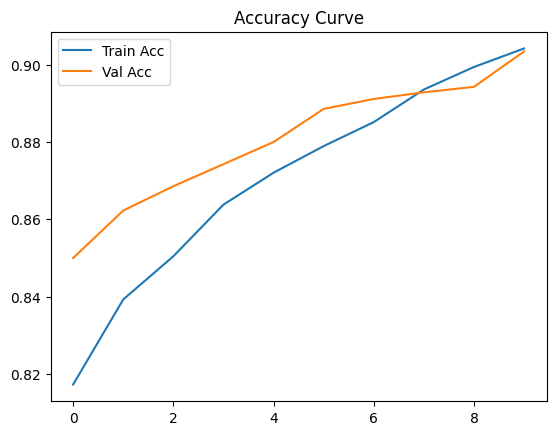

In [20]:
import matplotlib.pyplot as plt

plt.plot(fine_history.history['accuracy'], label='Train Acc')
plt.plot(fine_history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()


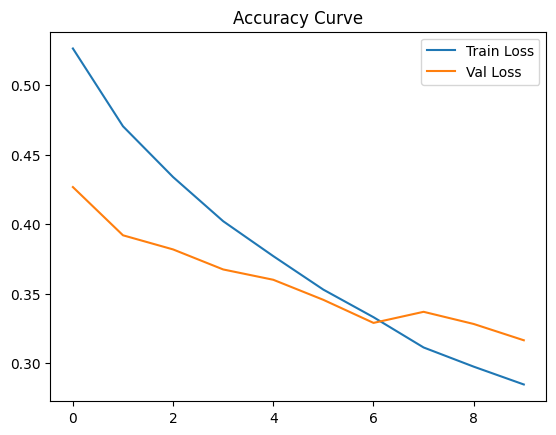

In [21]:
import matplotlib.pyplot as plt

plt.plot(fine_history.history['loss'], label='Train Loss')
plt.plot(fine_history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [ ]:
# ============================================================
# FINAL EVALUATION
# ============================================================
print("\nEvaluating on test data…")
results = model.evaluate(test_ds)
print("Test Results:", results)

In [32]:
# ============================================================
# SAVE
# ============================================================
model.save(os.path.join(OUTPUT_DIR, "convnext_tiny_final_improved.keras"))
print("\nFinal model saved successfully!")


Final model saved successfully!
